In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le fichier CSV
df = pd.read_csv('agriculture_burundi.csv')

print("✅ Données chargées avec succès !")
print(f"Nombre de lignes    : {df.shape[0]}")
print(f"Nombre de colonnes  : {df.shape[1]}")


✅ Données chargées avec succès !
Nombre de lignes    : 1620
Nombre de colonnes  : 14


In [99]:
# Voir les 5 premières lignes du dataset
print("=== APERÇU DES DONNÉES ===")
df.head()

=== APERÇU DES DONNÉES ===


,annee,saison,province,culture,altitude_m,pluviometrie_mm,temperature_moy_C,superficie_ha,utilisation_engrais,acces_irrigation,nb_menages,rendement_t_ha,production_totale_t,bonne_recolte
0,2015,A,Bujumbura Rural,Maïs,881,NaN,23.9,1.33,1.0,1,154,2.14,2.85,1.0
1,2015,A,Bujumbura Rural,Haricot,803,955.4,22.1,3.25,0.0,0,16,0.64,2.08,1.0
2,2015,A,Bujumbura Rural,Manioc,835,1060.3,24.9,1.71,1.0,1,103,13.38,22.88,1.0
3,2015,A,Bujumbura Rural,Patate douce,848,760.3,23.8,2.94,0.0,1,64,6.94,20.40,1.0
4,2015,A,Bujumbura Rural,Sorgho,837,1126.8,23.1,3.94,0.0,0,56,0.89,3.51,1.0


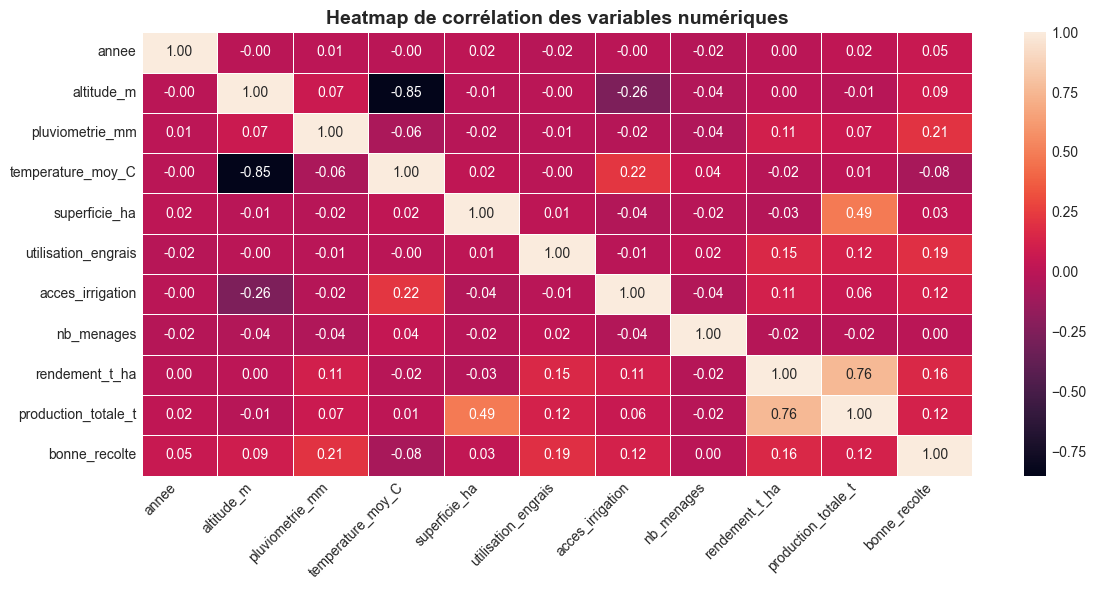

In [100]:
# === CELLULE 10 — HEATMAP DE CORRÉLATION ===
# Cette cellule affiche les corrélations entre les variables numériques du dataset.
# Une valeur proche de 1 indique une relation positive forte; proche de -1, une relation négative forte.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')

correlation = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Heatmap de corrélation des variables numériques', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


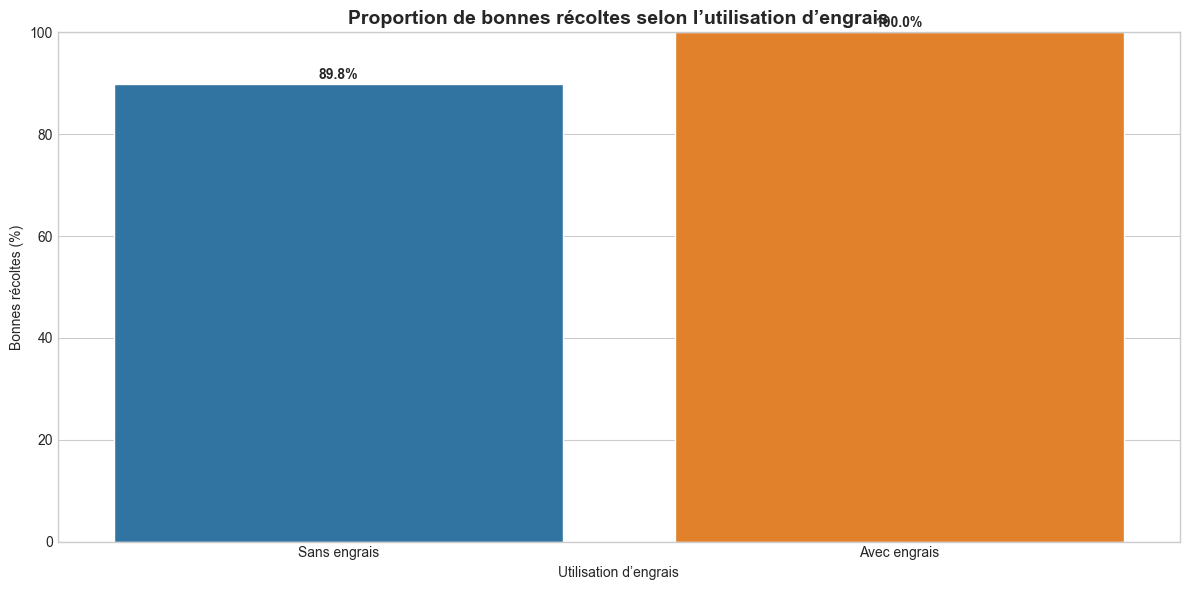

,Engrais,Proportion bonnes récoltes (%)
0,Sans engrais,89.812067
1,Avec engrais,100.000000


In [101]:
# === CELLULE 11 — BARPLOT BONNES RÉCOLTES SELON ENGRAIS ===
# La moyenne de bonne_recolte donne la proportion de bonnes récoltes car la variable vaut 0 ou 1.

plt.style.use('seaborn-v0_8-whitegrid')
engrais_recolte = (
    df.dropna(subset=['utilisation_engrais', 'bonne_recolte'])
      .groupby('utilisation_engrais')['bonne_recolte'].mean().reset_index()
)
engrais_recolte['Engrais'] = engrais_recolte['utilisation_engrais'].map({0: 'Sans engrais', 1: 'Avec engrais'})
engrais_recolte['Proportion bonnes récoltes (%)'] = engrais_recolte['bonne_recolte'] * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=engrais_recolte, x='Engrais', y='Proportion bonnes récoltes (%)',
            hue='Engrais', legend=False)
plt.title('Proportion de bonnes récoltes selon l’utilisation d’engrais', fontsize=14, fontweight='bold')
plt.xlabel('Utilisation d’engrais')
plt.ylabel('Bonnes récoltes (%)')
plt.ylim(0, 100)
for i, row in engrais_recolte.iterrows():
    plt.text(i, row['Proportion bonnes récoltes (%)'] + 1, f"{row['Proportion bonnes récoltes (%)']:.1f}%",
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
display(engrais_recolte[['Engrais', 'Proportion bonnes récoltes (%)']])


In [102]:
# === CELLULE 12 — ANALYSE DES MANQUANTS PAR PROVINCE ET CULTURE ===
# On vérifie si les valeurs manquantes sont concentrées dans certaines provinces ou cultures.

colonnes_manquantes = ['pluviometrie_mm', 'utilisation_engrais', 'rendement_t_ha', 'production_totale_t', 'bonne_recolte']

def resume_manquants_par_groupe(colonne_groupe):
    resume = df.groupby(colonne_groupe)[colonnes_manquantes].apply(lambda x: x.isna().sum())
    resume['total_manquants'] = resume.sum(axis=1)
    return resume.sort_values('total_manquants', ascending=False)

print('Valeurs manquantes par province :')
display(resume_manquants_par_groupe('province'))
print('Valeurs manquantes par culture :')
display(resume_manquants_par_groupe('culture'))


Valeurs manquantes par province :


,pluviometrie_mm,utilisation_engrais,rendement_t_ha,production_totale_t,bonne_recolte,total_manquants
province,,,,,,
Cankuzo,3,2,7,7,7,26
Makamba,4,3,5,5,5,22
Bubanza,4,4,4,4,4,20
Ruyigi,6,4,3,3,3,19
Rutana,4,2,4,4,4,18
Muyinga,4,5,3,3,3,18
Kayanza,2,7,3,3,3,18
Bururi,7,3,2,2,2,16
Kirundo,7,2,2,2,2,15


Valeurs manquantes par culture :


,pluviometrie_mm,utilisation_engrais,rendement_t_ha,production_totale_t,bonne_recolte,total_manquants
culture,,,,,,
Haricot,14,7,11,11,11,54
Patate douce,8,9,10,10,10,47
Bananier,9,10,7,7,7,40
Maïs,12,9,6,6,6,39
Sorgho,8,7,6,6,6,33
Manioc,12,3,4,4,4,27


In [103]:
# === CELLULE 13 — STATISTIQUES PAR CULTURE ET PROVINCE ===
# Cette cellule identifie les cultures les plus productives et les provinces les plus arrosées.

stats_culture = (
    df.groupby('culture')
      .agg(rendement_moyen_t_ha=('rendement_t_ha', 'mean'),
           production_moyenne_t=('production_totale_t', 'mean'),
           pluie_moyenne_mm=('pluviometrie_mm', 'mean'),
           proportion_bonnes_recoltes=('bonne_recolte', 'mean'))
      .sort_values('rendement_moyen_t_ha', ascending=False)
)
stats_culture['proportion_bonnes_recoltes'] *= 100
stats_province_pluie = df.groupby('province')['pluviometrie_mm'].mean().sort_values(ascending=False).reset_index(name='pluviometrie_moyenne_mm')

print(f"Culture avec le rendement moyen le plus élevé : {stats_culture['rendement_moyen_t_ha'].idxmax()}")
print(f"Culture avec le rendement moyen le plus faible : {stats_culture['rendement_moyen_t_ha'].idxmin()}")
print(f"Province avec la pluviométrie moyenne la plus forte : {stats_province_pluie.iloc[0]['province']}")
display(stats_culture.round(2))
display(stats_province_pluie.head(10).round(2))


Culture avec le rendement moyen le plus élevé : Manioc
Culture avec le rendement moyen le plus faible : Haricot
Province avec la pluviométrie moyenne la plus forte : Muramvya


,rendement_moyen_t_ha,production_moyenne_t,pluie_moyenne_mm,proportion_bonnes_recoltes
culture,,,,
Manioc,9.67,22.41,834.36,95.49
Bananier,7.27,17.93,841.11,95.44
Patate douce,6.68,15.22,850.94,94.23
Maïs,1.48,3.56,836.21,92.05
Sorgho,1.06,2.69,827.96,89.77
Haricot,0.85,1.99,830.15,93.05


,province,pluviometrie_moyenne_mm
0,Muramvya,855.22
1,Mwaro,854.92
2,Kayanza,852.22
3,Bururi,852.20
4,Gitega,846.38
5,Cankuzo,841.06
6,Makamba,836.72
7,Kirundo,831.13
8,Ruyigi,830.64
9,Rutana,830.21


In [104]:
# === CELLULE 14 — TRAITEMENT DES VALEURS MANQUANTES ===
# On prépare une copie propre du dataset. La cible bonne_recolte n'est pas imputée : ses lignes manquantes sont supprimées.

df_model = df.copy()
df_model['culture'] = df_model['culture'].replace({'MaÃ¯s': 'Maïs', 'Maļs': 'Maïs', 'Mais': 'Maïs'})
df_model = df_model.dropna(subset=['bonne_recolte']).copy()

df_model['pluviometrie_mm'] = df_model['pluviometrie_mm'].fillna(
    df_model.groupby(['province', 'culture'])['pluviometrie_mm'].transform('median')
)
df_model['pluviometrie_mm'] = df_model['pluviometrie_mm'].fillna(df_model['pluviometrie_mm'].median())

mode_engrais = df_model['utilisation_engrais'].mode()[0]
df_model['utilisation_engrais'] = df_model['utilisation_engrais'].fillna(mode_engrais)

for colonne in ['rendement_t_ha', 'production_totale_t']:
    df_model[colonne] = df_model[colonne].fillna(df_model.groupby('culture')[colonne].transform('median'))
    df_model[colonne] = df_model[colonne].fillna(df_model[colonne].median())

for colonne in ['utilisation_engrais', 'acces_irrigation', 'bonne_recolte']:
    df_model[colonne] = df_model[colonne].astype(int)

print('Valeurs manquantes après traitement :')
display(df_model.isna().sum().to_frame('nb_manquants'))
print(f"Dataset propre : {df_model.shape[0]} lignes et {df_model.shape[1]} colonnes")


Valeurs manquantes après traitement :


,nb_manquants
annee,0
saison,0
province,0
culture,0
altitude_m,0
pluviometrie_mm,0
temperature_moy_C,0
superficie_ha,0
utilisation_engrais,0
acces_irrigation,0


Dataset propre : 1576 lignes et 14 colonnes


In [105]:
# === CELLULE 15 — ENCODAGE DES VARIABLES CATÉGORIELLES ===
# LabelEncoder transforme les catégories textuelles en nombres utilisables par scikit-learn.
# Il est utilisé ici pour garder un prétraitement simple et réutilisable dans Streamlit.

from sklearn.preprocessing import LabelEncoder

colonnes_categorielles = ['saison', 'culture', 'province']
apercu_avant_encodage = df_model[colonnes_categorielles].head().copy()
df_encoded = df_model.copy()
encoders = {}

for colonne in colonnes_categorielles:
    encoder = LabelEncoder()
    df_encoded[colonne] = encoder.fit_transform(df_encoded[colonne])
    encoders[colonne] = encoder

print('Aperçu avant encodage :')
display(apercu_avant_encodage)
print('Aperçu après encodage :')
display(df_encoded[colonnes_categorielles].head())
print('Correspondances des encodeurs :')
for colonne, encoder in encoders.items():
    print(f"{colonne} : {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")


Aperçu avant encodage :


,saison,culture,province
0,A,Maïs,Bujumbura Rural
1,A,Haricot,Bujumbura Rural
2,A,Manioc,Bujumbura Rural
3,A,Patate douce,Bujumbura Rural
4,A,Sorgho,Bujumbura Rural


Aperçu après encodage :


,saison,culture,province
0,0,3,1
1,0,1,1
2,0,2,1
3,0,4,1
4,0,5,1


Correspondances des encodeurs :
saison : {'A': np.int64(0), 'B': np.int64(1)}
culture : {'Bananier': np.int64(0), 'Haricot': np.int64(1), 'Manioc': np.int64(2), 'Maïs': np.int64(3), 'Patate douce': np.int64(4), 'Sorgho': np.int64(5)}
province : {'Bubanza': np.int64(0), 'Bujumbura Rural': np.int64(1), 'Bururi': np.int64(2), 'Cankuzo': np.int64(3), 'Cibitoke': np.int64(4), 'Gitega': np.int64(5), 'Kayanza': np.int64(6), 'Kirundo': np.int64(7), 'Makamba': np.int64(8), 'Muramvya': np.int64(9), 'Muyinga': np.int64(10), 'Mwaro': np.int64(11), 'Ngozi': np.int64(12), 'Rutana': np.int64(13), 'Ruyigi': np.int64(14)}


In [106]:
# === CELLULE 16 — SÉLECTION DES FEATURES ET CIBLE ===
# On exclut rendement_t_ha et production_totale_t car ces variables sont connues après la récolte.
# Les utiliser causerait du data leakage : le modèle verrait indirectement la réponse.

colonnes_a_exclure = ['rendement_t_ha', 'production_totale_t', 'bonne_recolte']
X = df_encoded.drop(columns=colonnes_a_exclure)
y = df_encoded['bonne_recolte']

print('Variables explicatives utilisées :')
print(X.columns.tolist())
print(f"Taille de X : {X.shape}")
print(f"Taille de y : {y.shape}")
display(y.value_counts(normalize=True).mul(100).round(2).to_frame('proportion_%'))


Variables explicatives utilisées :
['annee', 'saison', 'province', 'culture', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'utilisation_engrais', 'acces_irrigation', 'nb_menages']
Taille de X : (1576, 11)
Taille de y : (1576,)


,proportion_%
bonne_recolte,
1,93.34
0,6.66


In [107]:
# === CELLULE 17 — NORMALISATION ===
# StandardScaler est appliqué uniquement aux variables numériques continues.
# Les variables binaires et les variables encodées ne sont pas normalisées.

from sklearn.preprocessing import StandardScaler

X_scaled = X.copy()
colonnes_continues = ['annee', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'nb_menages']
scaler = StandardScaler()
X_scaled[colonnes_continues] = scaler.fit_transform(X_scaled[colonnes_continues])

verification_normalisation = pd.DataFrame({
    'moyenne_apres_normalisation': X_scaled[colonnes_continues].mean().round(4),
    'ecart_type_apres_normalisation': X_scaled[colonnes_continues].std().round(4)
})
display(verification_normalisation)
display(X_scaled.head())


,moyenne_apres_normalisation,ecart_type_apres_normalisation
annee,-0.0,1.0003
altitude_m,-0.0,1.0003
pluviometrie_mm,-0.0,1.0003
temperature_moy_C,0.0,1.0003
superficie_ha,-0.0,1.0003
nb_menages,-0.0,1.0003


,annee,saison,province,culture,altitude_m,pluviometrie_mm,temperature_moy_C,superficie_ha,utilisation_engrais,acces_irrigation,nb_menages
0,-1.546602,0,1,3,-1.365854,-0.048642,1.703501,-0.868335,1,1,1.187502
1,-1.546602,0,1,1,-1.559283,0.852272,0.564165,0.699412,0,0,-1.696170
2,-1.546602,0,1,2,-1.479927,1.605307,2.336465,-0.558052,1,1,0.121797
3,-1.546602,0,1,4,-1.447689,-0.548272,1.640204,0.446286,0,1,-0.693154
4,-1.546602,0,1,5,-1.474967,2.082684,1.197130,1.262821,0,0,-0.860323


In [108]:
# === CELLULE 18 — DIVISION TRAIN/TEST ===
# On réserve 20% des données pour le test. stratify=y conserve une proportion similaire de bonnes récoltes.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Taille X_train : {X_train.shape}")
print(f"Taille X_test  : {X_test.shape}")
print(f"Taille y_train : {y_train.shape}")
print(f"Taille y_test  : {y_test.shape}")
display(pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True).mul(100).round(2),
    'Test (%)': y_test.value_counts(normalize=True).mul(100).round(2)
}).sort_index())


Taille X_train : (1260, 11)
Taille X_test  : (316, 11)
Taille y_train : (1260,)
Taille y_test  : (316,)


,Train (%),Test (%)
bonne_recolte,,
0,6.67,6.65
1,93.33,93.35


In [109]:
# === CELLULE 19 — ENTRAÎNEMENT ARBRE DE DÉCISION ===
# L'arbre apprend des règles simples. max_depth=4 limite la complexité et réduit l'overfitting.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time

debut = time.time()
model_arbre = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
model_arbre.fit(X_train, y_train)
temps_arbre = time.time() - debut

y_pred_arbre_train = model_arbre.predict(X_train)
y_pred_arbre = model_arbre.predict(X_test)
accuracy_arbre_train = accuracy_score(y_train, y_pred_arbre_train)
accuracy_arbre_test = accuracy_score(y_test, y_pred_arbre)

print(f"Accuracy train arbre de décision : {accuracy_arbre_train:.4f}")
print(f"Accuracy test arbre de décision  : {accuracy_arbre_test:.4f}")
print(f"Temps d'entraînement : {temps_arbre:.4f} seconde(s)")


Accuracy train arbre de décision : 0.9373
Accuracy test arbre de décision  : 0.8987
Temps d'entraînement : 0.0286 seconde(s)


Rapport de classification — Arbre de décision :
                  precision    recall  f1-score   support

Mauvaise récolte       0.26      0.29      0.27        21
   Bonne récolte       0.95      0.94      0.95       295

        accuracy                           0.90       316
       macro avg       0.60      0.61      0.61       316
    weighted avg       0.90      0.90      0.90       316



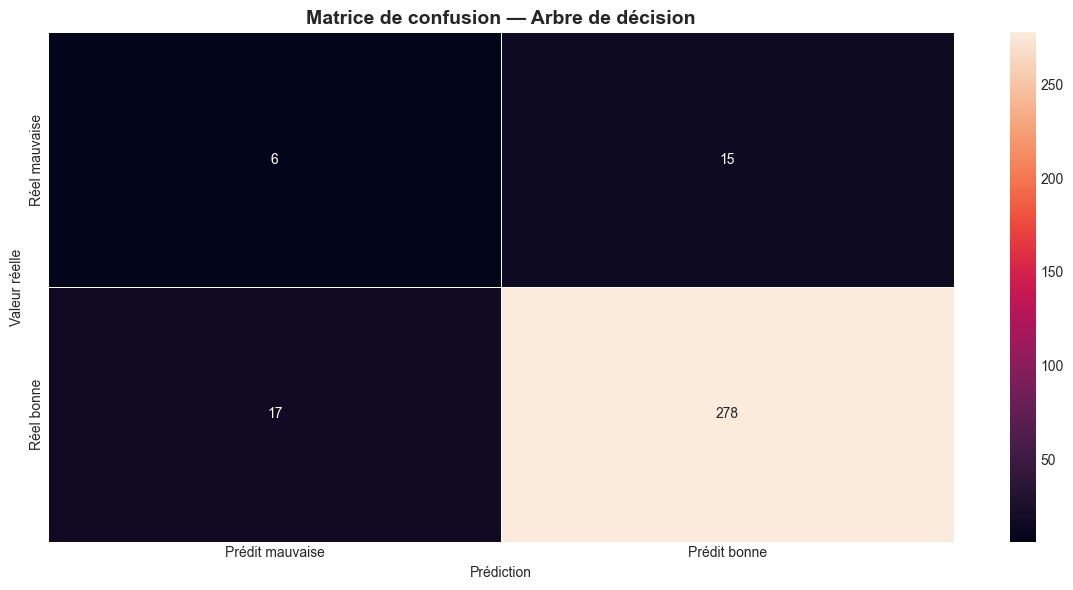

Faux positifs : 15
Faux négatifs : 17
Pour un agriculteur, le faux positif est souvent le plus coûteux : croire à une bonne récolte peut retarder l'irrigation ou les actions de prévention.


In [110]:
# === CELLULE 20 — RAPPORT DE CLASSIFICATION ET MATRICE DE CONFUSION ===
# Faux positif : prédire bonne récolte alors qu'elle est mauvaise. Faux négatif : prédire mauvaise alors qu'elle est bonne.

from sklearn.metrics import classification_report, confusion_matrix

print('Rapport de classification — Arbre de décision :')
print(classification_report(y_test, y_pred_arbre, target_names=['Mauvaise récolte', 'Bonne récolte'], zero_division=0))
cm_arbre = confusion_matrix(y_test, y_pred_arbre)
TN, FP, FN, TP = cm_arbre.ravel()

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
sns.heatmap(cm_arbre, annot=True, fmt='d',             xticklabels=['Prédit mauvaise', 'Prédit bonne'],
            yticklabels=['Réel mauvaise', 'Réel bonne'],
            linewidths=0.5)
plt.title('Matrice de confusion — Arbre de décision', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction')
plt.ylabel('Valeur réelle')
plt.tight_layout()
plt.show()

print(f"Faux positifs : {FP}")
print(f"Faux négatifs : {FN}")
print("Pour un agriculteur, le faux positif est souvent le plus coûteux : croire à une bonne récolte peut retarder l'irrigation ou les actions de prévention.")


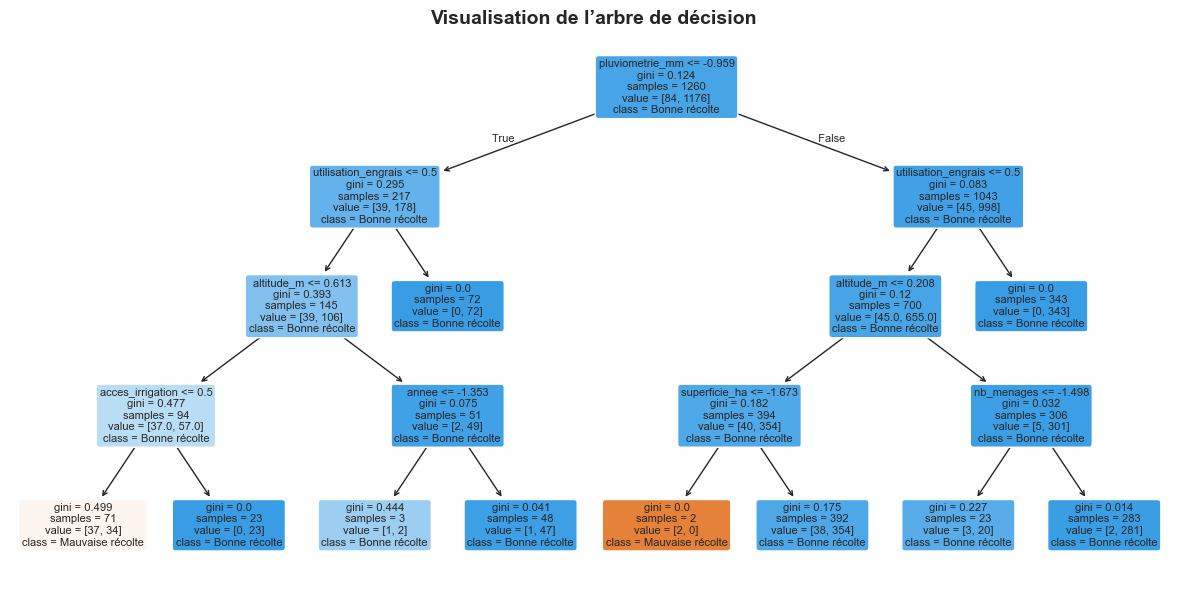

Variable racine du premier split : pluviometrie_mm
Seuil normalisé du premier split : -0.9592
Interprétation agronomique : le modèle commence par séparer les récoltes selon pluviometrie_mm, signe que cette variable est importante dans les conditions de production.


In [111]:
# === CELLULE 21 — VISUALISATION DE L’ARBRE ===
# Le premier nœud correspond à la variable racine : la première règle utilisée par le modèle.

from sklearn.tree import plot_tree

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
plot_tree(model_arbre, feature_names=X_train.columns, class_names=['Mauvaise récolte', 'Bonne récolte'],
          filled=True, rounded=True, max_depth=4, fontsize=8)
plt.title('Visualisation de l’arbre de décision', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

variable_racine = X_train.columns[model_arbre.tree_.feature[0]]
seuil_racine = model_arbre.tree_.threshold[0]
print(f"Variable racine du premier split : {variable_racine}")
print(f"Seuil normalisé du premier split : {seuil_racine:.4f}")
print(f"Interprétation agronomique : le modèle commence par séparer les récoltes selon {variable_racine}, signe que cette variable est importante dans les conditions de production.")


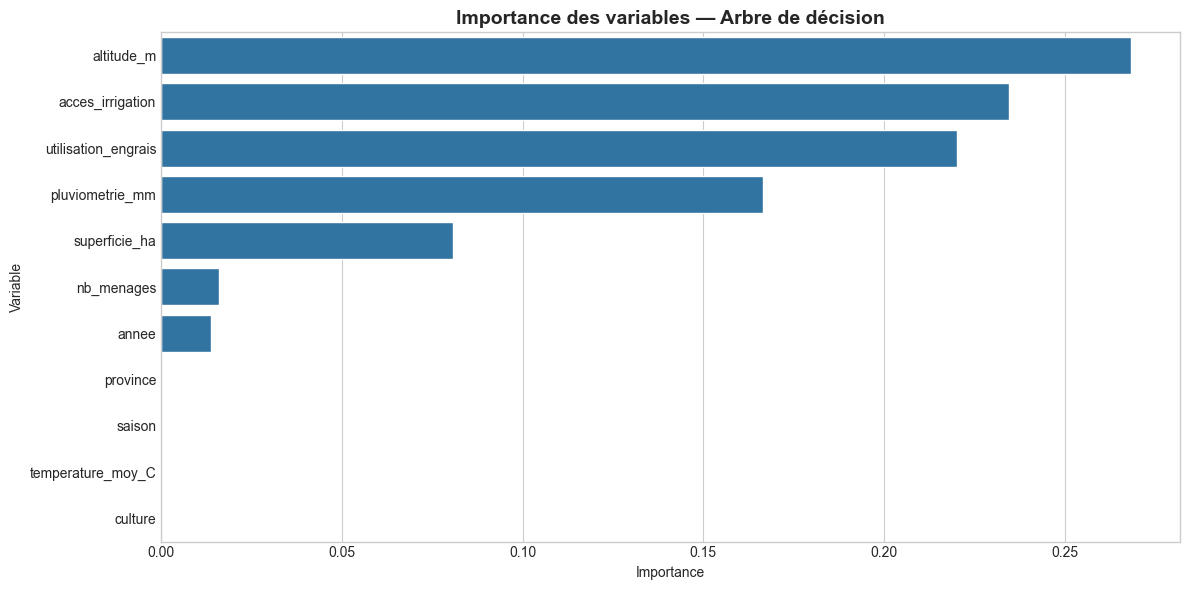

Top 3 des variables les plus importantes pour l’arbre :


,variable,importance_arbre
4,altitude_m,0.268441
9,acces_irrigation,0.234428
8,utilisation_engrais,0.220213


Commentaire : ces variables sont les plus utiles pour distinguer bonnes et mauvaises récoltes dans ce dataset.


In [112]:
# === CELLULE 22 — IMPORTANCE DES VARIABLES (ARBRE) ===
# Les importances montrent quelles variables contribuent le plus aux décisions de l'arbre.

importance_arbre = pd.DataFrame({
    'variable': X_train.columns,
    'importance_arbre': model_arbre.feature_importances_
}).sort_values('importance_arbre', ascending=False)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
sns.barplot(data=importance_arbre, x='importance_arbre', y='variable')
plt.title('Importance des variables — Arbre de décision', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print('Top 3 des variables les plus importantes pour l’arbre :')
display(importance_arbre.head(3))
print('Commentaire : ces variables sont les plus utiles pour distinguer bonnes et mauvaises récoltes dans ce dataset.')


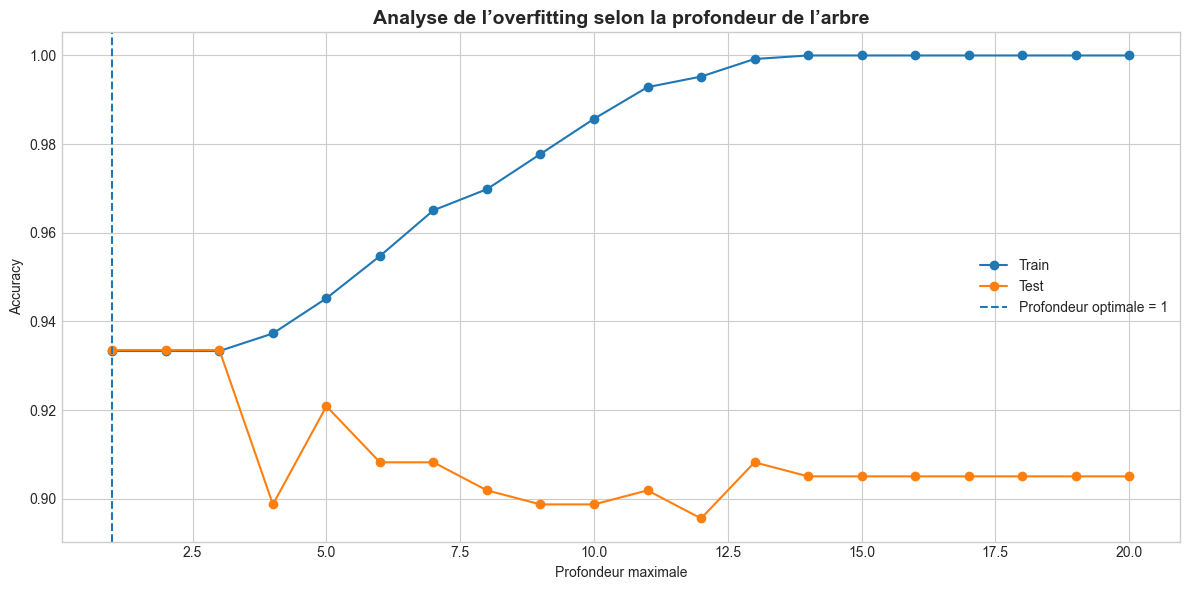

Profondeur optimale selon l'accuracy test : 1
Début probable de l'overfitting : profondeur 7


,profondeur,accuracy_train,accuracy_test
0,1,0.9333,0.9335
1,2,0.9333,0.9335
2,3,0.9333,0.9335
3,4,0.9373,0.8987
4,5,0.9452,0.9209
5,6,0.9548,0.9082
6,7,0.9651,0.9082
7,8,0.9698,0.9019
8,9,0.9778,0.8987
9,10,0.9857,0.8987


In [113]:
# === CELLULE 23 — ANALYSE OVERFITTING ===
# L'overfitting commence quand l'accuracy train augmente alors que l'accuracy test stagne ou diminue.

profondeurs = range(1, 21)
accuracies_train, accuracies_test = [], []
for depth in profondeurs:
    arbre_temp = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42)
    arbre_temp.fit(X_train, y_train)
    accuracies_train.append(accuracy_score(y_train, arbre_temp.predict(X_train)))
    accuracies_test.append(accuracy_score(y_test, arbre_temp.predict(X_test)))

resultats_depth = pd.DataFrame({'profondeur': list(profondeurs), 'accuracy_train': accuracies_train, 'accuracy_test': accuracies_test})
profondeur_optimale = int(resultats_depth.loc[resultats_depth['accuracy_test'].idxmax(), 'profondeur'])
surapprentissage = resultats_depth[(resultats_depth['profondeur'] > profondeur_optimale) & ((resultats_depth['accuracy_train'] - resultats_depth['accuracy_test']) > 0.05)]
profondeur_overfit = int(surapprentissage.iloc[0]['profondeur']) if not surapprentissage.empty else profondeur_optimale

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
plt.plot(resultats_depth['profondeur'], resultats_depth['accuracy_train'], marker='o', label='Train')
plt.plot(resultats_depth['profondeur'], resultats_depth['accuracy_test'], marker='o', label='Test')
plt.axvline(profondeur_optimale, linestyle='--', label=f'Profondeur optimale = {profondeur_optimale}')
plt.title('Analyse de l’overfitting selon la profondeur de l’arbre', fontsize=14, fontweight='bold')
plt.xlabel('Profondeur maximale')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Profondeur optimale selon l'accuracy test : {profondeur_optimale}")
print(f"Début probable de l'overfitting : profondeur {profondeur_overfit}")
display(resultats_depth.round(4))


In [114]:
# === CELLULE 24 — ENTRAÎNEMENT FORÊT ALÉATOIRE ===
# La forêt aléatoire combine plusieurs arbres pour obtenir une prédiction plus robuste.

from sklearn.ensemble import RandomForestClassifier

debut = time.time()
model_foret = RandomForestClassifier(n_estimators=100, random_state=42)
model_foret.fit(X_train, y_train)
temps_foret = time.time() - debut

y_pred_foret_train = model_foret.predict(X_train)
y_pred_foret = model_foret.predict(X_test)
accuracy_foret_train = accuracy_score(y_train, y_pred_foret_train)
accuracy_foret_test = accuracy_score(y_test, y_pred_foret)

comparaison_arbre_foret = pd.DataFrame({
    'Modèle': ['Arbre de décision', 'Forêt aléatoire'],
    'Accuracy Train': [accuracy_arbre_train, accuracy_foret_train],
    'Accuracy Test': [accuracy_arbre_test, accuracy_foret_test]
})
print(f"Accuracy test forêt aléatoire : {accuracy_foret_test:.4f}")
print(f"Temps d'entraînement : {temps_foret:.4f} seconde(s)")
display(comparaison_arbre_foret.round(4))


Accuracy test forêt aléatoire : 0.9335
Temps d'entraînement : 0.4076 seconde(s)


,Modèle,Accuracy Train,Accuracy Test
0,Arbre de décision,0.9373,0.8987
1,Forêt aléatoire,1.0000,0.9335


Rapport de classification — Forêt aléatoire :
                  precision    recall  f1-score   support

Mauvaise récolte       0.50      0.10      0.16        21
   Bonne récolte       0.94      0.99      0.97       295

        accuracy                           0.93       316
       macro avg       0.72      0.54      0.56       316
    weighted avg       0.91      0.93      0.91       316



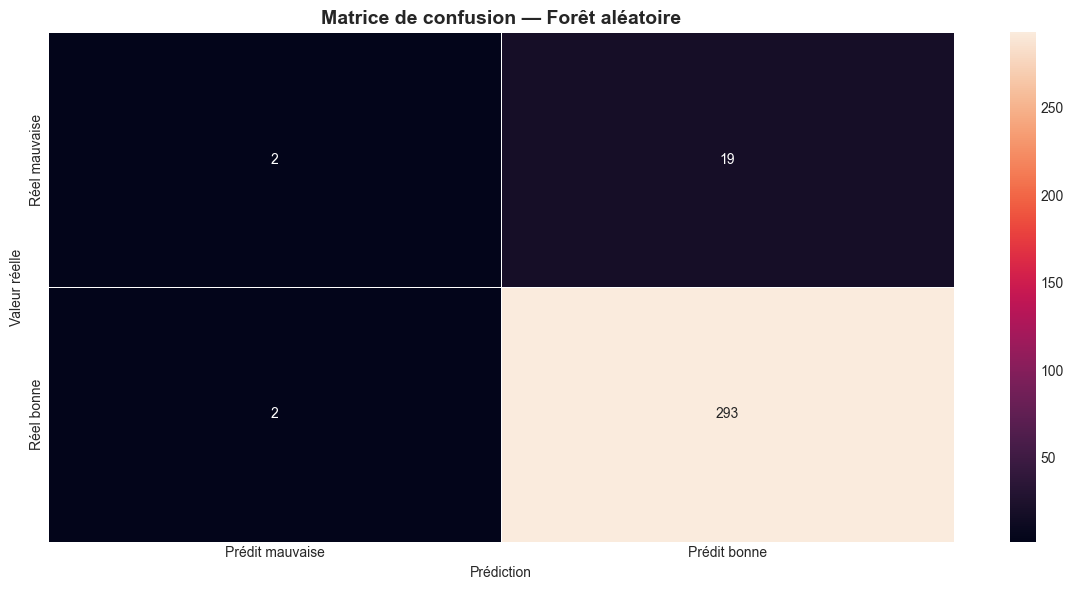

In [115]:
# === CELLULE 25 — RAPPORT ET MATRICE DE CONFUSION FORÊT ===
# On évalue la forêt aléatoire avec les mêmes métriques que l'arbre de décision.

print('Rapport de classification — Forêt aléatoire :')
print(classification_report(y_test, y_pred_foret, target_names=['Mauvaise récolte', 'Bonne récolte'], zero_division=0))
cm_foret = confusion_matrix(y_test, y_pred_foret)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
sns.heatmap(cm_foret, annot=True, fmt='d',             xticklabels=['Prédit mauvaise', 'Prédit bonne'],
            yticklabels=['Réel mauvaise', 'Réel bonne'],
            linewidths=0.5)
plt.title('Matrice de confusion — Forêt aléatoire', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction')
plt.ylabel('Valeur réelle')
plt.tight_layout()
plt.show()


In [116]:
# === CELLULE 26 — VALIDATION CROISÉE ===
# La validation croisée teste la forêt sur 5 découpages différents du dataset.

from sklearn.model_selection import cross_val_score

scores_cv_foret = cross_val_score(model_foret, X_scaled, y, cv=5, scoring='accuracy')
print('Scores des 5 folds :', np.round(scores_cv_foret, 4))
print(f"Moyenne validation croisée : {scores_cv_foret.mean():.4f}")
print(f"Écart-type validation croisée : {scores_cv_foret.std():.4f}")
print(f"Accuracy simple sur le test : {accuracy_foret_test:.4f}")


Scores des 5 folds : [0.9399 0.9302 0.927  0.9333 0.927 ]
Moyenne validation croisée : 0.9315
Écart-type validation croisée : 0.0048
Accuracy simple sur le test : 0.9335


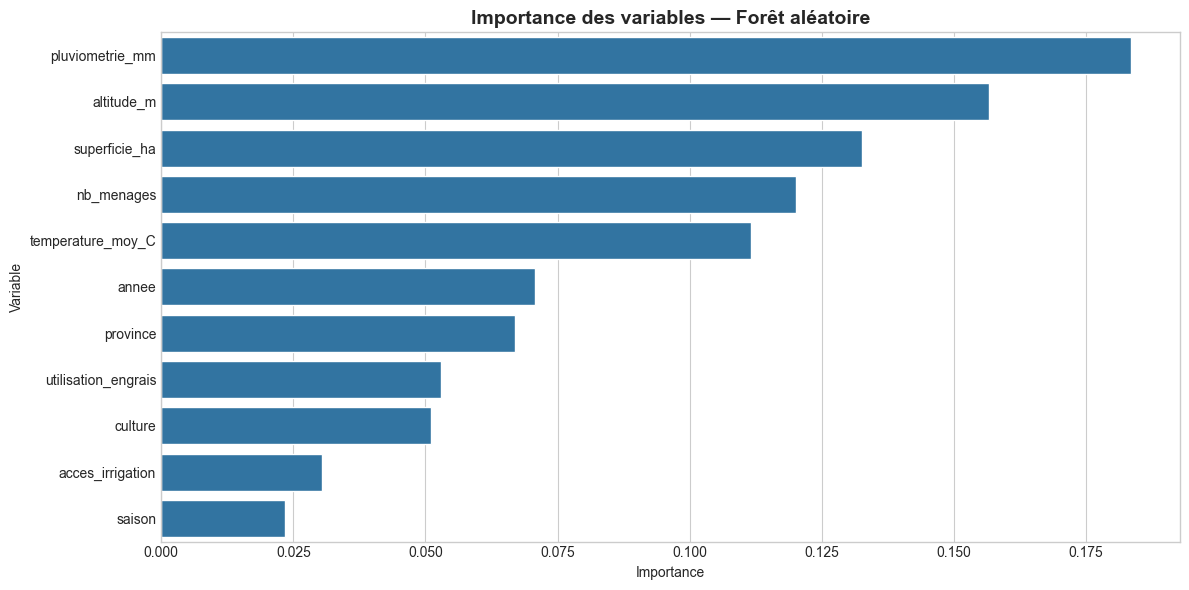

,Rang,Top arbre,Top forêt
0,1,altitude_m,pluviometrie_mm
1,2,acces_irrigation,altitude_m
2,3,utilisation_engrais,superficie_ha
3,4,pluviometrie_mm,nb_menages
4,5,superficie_ha,temperature_moy_C


In [117]:
# === CELLULE 27 — IMPORTANCE DES VARIABLES (FORÊT) ===
# La forêt calcule une importance moyenne sur l'ensemble de ses arbres.

importance_foret = pd.DataFrame({
    'variable': X_train.columns,
    'importance_foret': model_foret.feature_importances_
}).sort_values('importance_foret', ascending=False)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
sns.barplot(data=importance_foret, x='importance_foret', y='variable')
plt.title('Importance des variables — Forêt aléatoire', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

top5_comparatif = pd.DataFrame({
    'Rang': range(1, 6),
    'Top arbre': importance_arbre.head(5)['variable'].values,
    'Top forêt': importance_foret.head(5)['variable'].values
})
display(top5_comparatif)


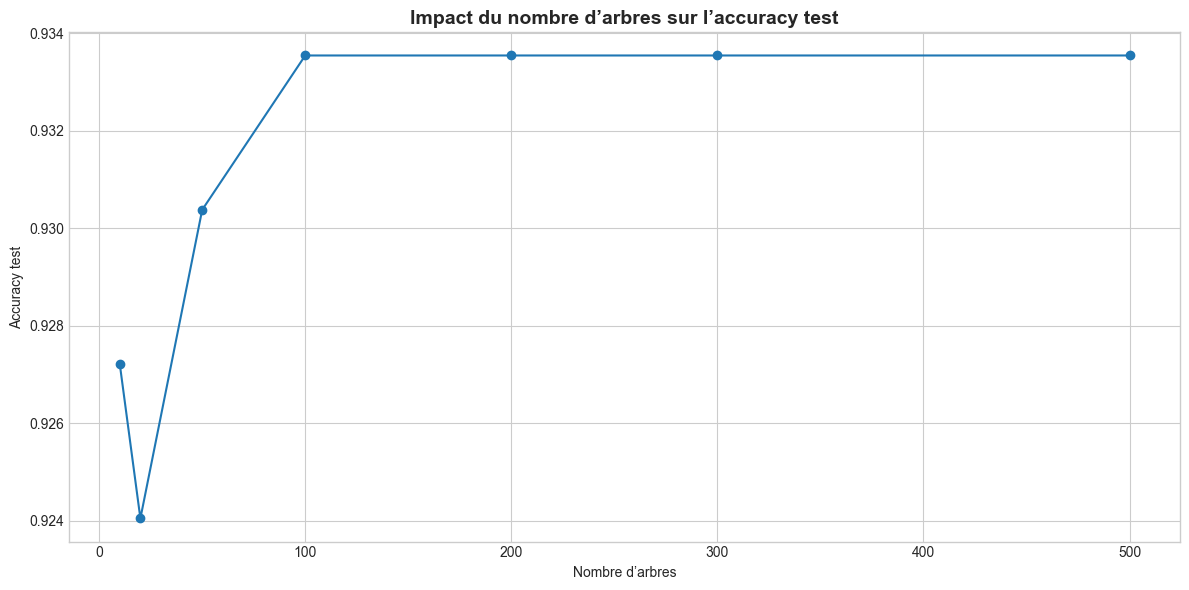

Performance stabilisée approximativement à partir de 200 arbres.


,n_estimators,accuracy_test
0,10,0.9272
1,20,0.9241
2,50,0.9304
3,100,0.9335
4,200,0.9335
5,300,0.9335
6,500,0.9335


In [118]:
# === CELLULE 28 — IMPACT DU NOMBRE D’ARBRES ===
# On teste plusieurs valeurs de n_estimators pour voir à partir de quand la performance se stabilise.

liste_n_estimators = [10, 20, 50, 100, 200, 300, 500]
accuracies_n_estimators = []
for n in liste_n_estimators:
    foret_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    foret_temp.fit(X_train, y_train)
    accuracies_n_estimators.append(accuracy_score(y_test, foret_temp.predict(X_test)))

impact_arbres = pd.DataFrame({'n_estimators': liste_n_estimators, 'accuracy_test': accuracies_n_estimators})
stabilisation = impact_arbres['n_estimators'].iloc[-1]
for i in range(1, len(impact_arbres)):
    if abs(impact_arbres.loc[i, 'accuracy_test'] - impact_arbres.loc[i - 1, 'accuracy_test']) < 0.002:
        stabilisation = impact_arbres.loc[i, 'n_estimators']
        break

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
plt.plot(impact_arbres['n_estimators'], impact_arbres['accuracy_test'], marker='o')
plt.title('Impact du nombre d’arbres sur l’accuracy test', fontsize=14, fontweight='bold')
plt.xlabel('Nombre d’arbres')
plt.ylabel('Accuracy test')
plt.tight_layout()
plt.show()
print(f"Performance stabilisée approximativement à partir de {stabilisation} arbres.")
display(impact_arbres.round(4))


In [119]:
# === CELLULE 29 — ENTRAÎNEMENT RÉGRESSION LOGISTIQUE ===
# La régression logistique est un modèle linéaire adapté à la classification binaire.

from sklearn.linear_model import LogisticRegression

debut = time.time()
model_regression = LogisticRegression(max_iter=1000, random_state=42)
model_regression.fit(X_train, y_train)
temps_regression = time.time() - debut

y_pred_regression_train = model_regression.predict(X_train)
y_pred_regression = model_regression.predict(X_test)
accuracy_regression_train = accuracy_score(y_train, y_pred_regression_train)
accuracy_regression_test = accuracy_score(y_test, y_pred_regression)

comparaison_3_modeles = pd.DataFrame({
    'Modèle': ['Arbre de décision', 'Forêt aléatoire', 'Régression logistique'],
    'Accuracy Train': [accuracy_arbre_train, accuracy_foret_train, accuracy_regression_train],
    'Accuracy Test': [accuracy_arbre_test, accuracy_foret_test, accuracy_regression_test]
})
print(f"Accuracy test régression logistique : {accuracy_regression_test:.4f}")
print(f"Temps d'entraînement : {temps_regression:.4f} seconde(s)")
display(comparaison_3_modeles.round(4))


Accuracy test régression logistique : 0.9335
Temps d'entraînement : 0.0340 seconde(s)


,Modèle,Accuracy Train,Accuracy Test
0,Arbre de décision,0.9373,0.8987
1,Forêt aléatoire,1.0000,0.9335
2,Régression logistique,0.9349,0.9335


Rapport de classification — Régression logistique :
                  precision    recall  f1-score   support

Mauvaise récolte       0.50      0.05      0.09        21
   Bonne récolte       0.94      1.00      0.97       295

        accuracy                           0.93       316
       macro avg       0.72      0.52      0.53       316
    weighted avg       0.91      0.93      0.91       316



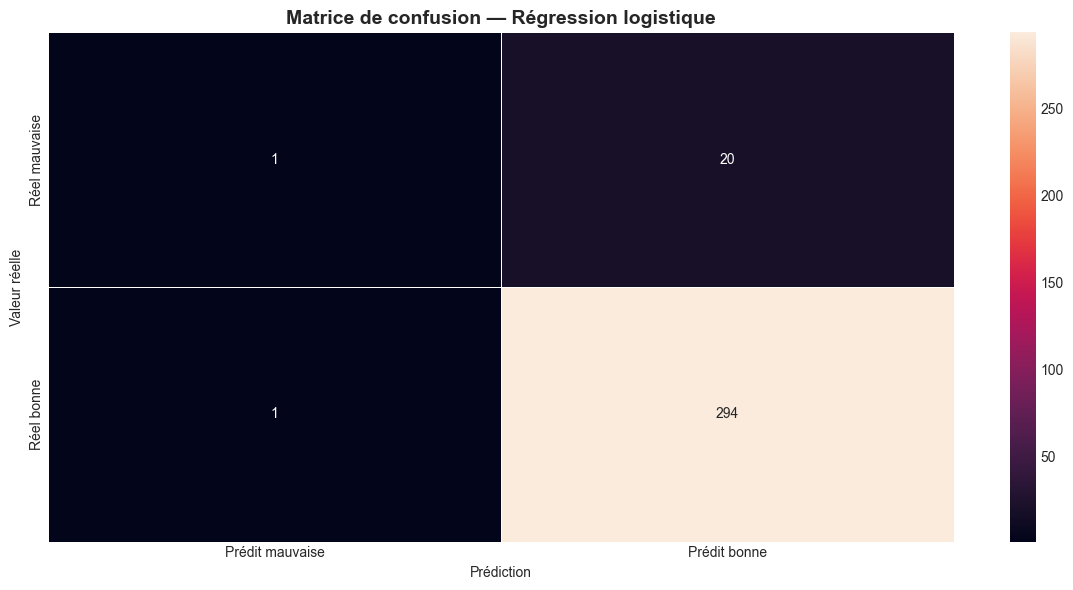

In [120]:
# === CELLULE 30 — RAPPORT ET MATRICE DE CONFUSION RÉGRESSION ===
# On évalue la régression logistique avec le même protocole que les autres modèles.

print('Rapport de classification — Régression logistique :')
print(classification_report(y_test, y_pred_regression, target_names=['Mauvaise récolte', 'Bonne récolte'], zero_division=0))
cm_regression = confusion_matrix(y_test, y_pred_regression)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
sns.heatmap(cm_regression, annot=True, fmt='d',             xticklabels=['Prédit mauvaise', 'Prédit bonne'],
            yticklabels=['Réel mauvaise', 'Réel bonne'],
            linewidths=0.5)
plt.title('Matrice de confusion — Régression logistique', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction')
plt.ylabel('Valeur réelle')
plt.tight_layout()
plt.show()


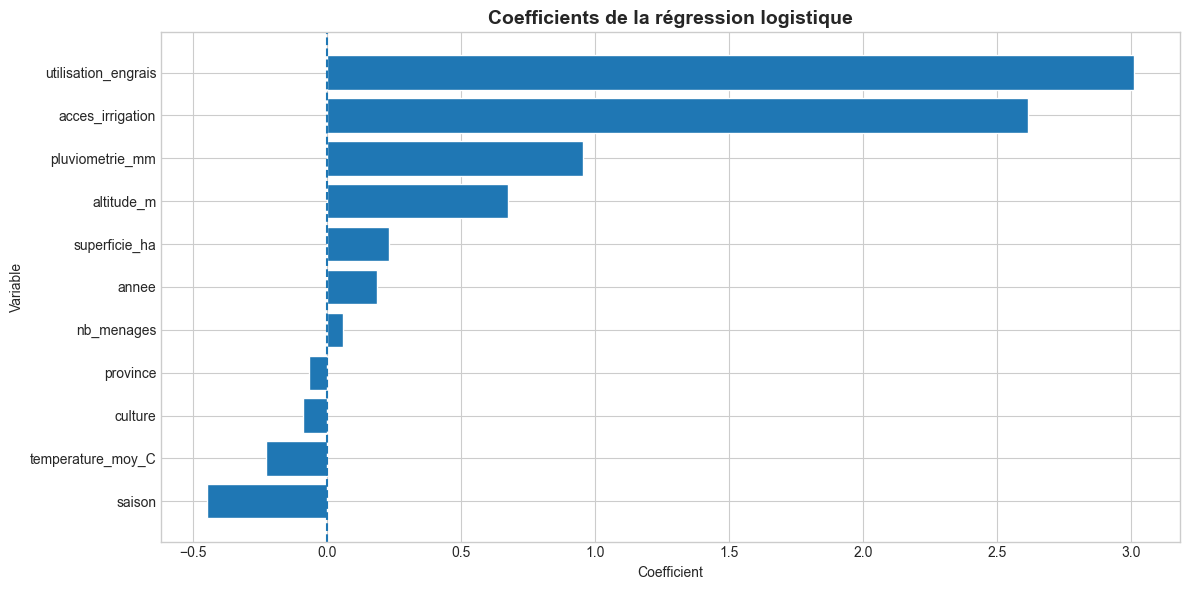

Variables avec coefficients les plus positifs :


,variable,coefficient
8,utilisation_engrais,3.009334
9,acces_irrigation,2.615928
5,pluviometrie_mm,0.954995


Variables avec coefficients les plus négatifs :


,variable,coefficient
1,saison,-0.445583
6,temperature_moy_C,-0.228612
3,culture,-0.090190


Interprétation : le signe positif indique un facteur associé à une meilleure probabilité de bonne récolte; le signe négatif indique un facteur de risque.


In [121]:
# === CELLULE 31 — COEFFICIENTS ET INTERPRÉTATION ===
# Un coefficient positif augmente la probabilité de bonne récolte; un coefficient négatif la diminue.

coefficients_regression = pd.DataFrame({
    'variable': X_train.columns,
    'coefficient': model_regression.coef_[0]
}).sort_values('coefficient')

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
plt.barh(coefficients_regression['variable'], coefficients_regression['coefficient'])
plt.axvline(0, linestyle='--')
plt.title('Coefficients de la régression logistique', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print('Variables avec coefficients les plus positifs :')
display(coefficients_regression.sort_values('coefficient', ascending=False).head(3))
print('Variables avec coefficients les plus négatifs :')
display(coefficients_regression.head(3))
print('Interprétation : le signe positif indique un facteur associé à une meilleure probabilité de bonne récolte; le signe négatif indique un facteur de risque.')


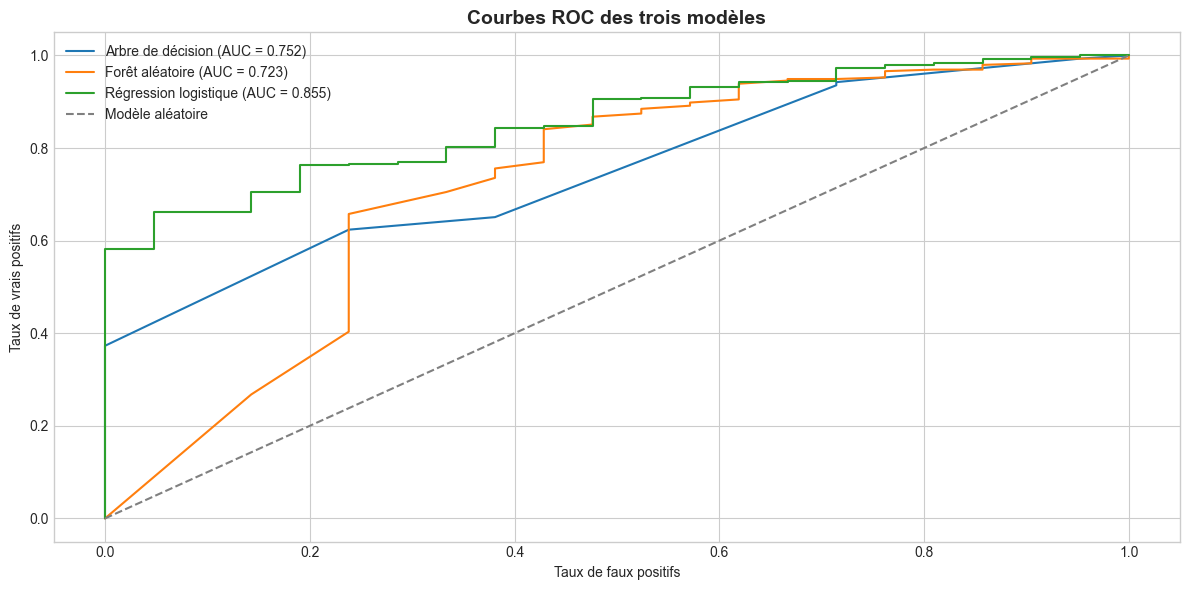

In [122]:
# === CELLULE 32 — COURBE ROC DES 3 MODÈLES ===
# L'AUC mesure la capacité du modèle à séparer bonnes et mauvaises récoltes.

from sklearn.metrics import roc_curve, roc_auc_score

proba_arbre = model_arbre.predict_proba(X_test)[:, 1]
proba_foret = model_foret.predict_proba(X_test)[:, 1]
proba_regression = model_regression.predict_proba(X_test)[:, 1]
auc_arbre = roc_auc_score(y_test, proba_arbre)
auc_foret = roc_auc_score(y_test, proba_foret)
auc_regression = roc_auc_score(y_test, proba_regression)
fpr_arbre, tpr_arbre, _ = roc_curve(y_test, proba_arbre)
fpr_foret, tpr_foret, _ = roc_curve(y_test, proba_foret)
fpr_regression, tpr_regression, _ = roc_curve(y_test, proba_regression)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
plt.plot(fpr_arbre, tpr_arbre, label=f'Arbre de décision (AUC = {auc_arbre:.3f})')
plt.plot(fpr_foret, tpr_foret, label=f'Forêt aléatoire (AUC = {auc_foret:.3f})')
plt.plot(fpr_regression, tpr_regression, label=f'Régression logistique (AUC = {auc_regression:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Modèle aléatoire')
plt.title('Courbes ROC des trois modèles', fontsize=14, fontweight='bold')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.legend()
plt.tight_layout()
plt.show()


In [123]:
# === CELLULE 33 — TABLEAU COMPARATIF FINAL DES 3 MODÈLES ===
# Le F1-score utilisé est celui de la classe positive : bonne récolte.

from sklearn.metrics import f1_score

f1_arbre = f1_score(y_test, y_pred_arbre, zero_division=0)
f1_foret = f1_score(y_test, y_pred_foret, zero_division=0)
f1_regression = f1_score(y_test, y_pred_regression, zero_division=0)

tableau_final = pd.DataFrame({
    'Modèle': ['Arbre de décision', 'Forêt aléatoire', 'Régression logistique'],
    'Accuracy': [accuracy_arbre_test, accuracy_foret_test, accuracy_regression_test],
    'F1-score': [f1_arbre, f1_foret, f1_regression],
    'AUC': [auc_arbre, auc_foret, auc_regression],
    "Temps d'entraînement (s)": [temps_arbre, temps_foret, temps_regression]
})
meilleur_modele = tableau_final.sort_values(['AUC', 'F1-score', 'Accuracy'], ascending=False).iloc[0]
display(tableau_final.round(4))
print(f"Modèle recommandé : {meilleur_modele['Modèle']}")
print("Conclusion : le modèle est choisi en priorité selon l'AUC, puis le F1-score et l'accuracy, car la cible est déséquilibrée.")


,Modèle,Accuracy,F1-score,AUC,Temps d'entraînement (s)
0,Arbre de décision,0.8987,0.9456,0.7520,0.0286
1,Forêt aléatoire,0.9335,0.9654,0.7225,0.4076
2,Régression logistique,0.9335,0.9655,0.8554,0.0340


Modèle recommandé : Régression logistique
Conclusion : le modèle est choisi en priorité selon l'AUC, puis le F1-score et l'accuracy, car la cible est déséquilibrée.


In [124]:
# === CELLULE 34 — PRÉPARATION DES SCÉNARIOS ===
# On applique le même encodage et la même normalisation que sur l'entraînement.
# Pour les nouveaux scénarios, on utilise transform() et jamais fit_transform().

scenarios = pd.DataFrame({
    'annee': [2024, 2024, 2024, 2024],
    'saison': ['A', 'A', 'A', 'A'],
    'province': ['Kayanza', 'Bubanza', 'Gitega', 'Cibitoke'],
    'culture': ['Maïs', 'Manioc', 'Haricot', 'Patate douce'],
    'altitude_m': [1980, 790, 1720, 810],
    'pluviometrie_mm': [920, 550, 430, 810],
    'temperature_moy_C': [17.8, 25.4, 18.2, 24.1],
    'superficie_ha': [2.5, 1.8, 3.2, 2.0],
    'utilisation_engrais': [1, 0, 0, 1],
    'acces_irrigation': [0, 1, 0, 1],
    'nb_menages': [120, 45, 200, 78]
})
scenarios_affichage = pd.DataFrame({
    'Province': scenarios['province'], 'Culture': scenarios['culture'], 'Altitude': scenarios['altitude_m'],
    'Pluie (mm)': scenarios['pluviometrie_mm'], 'Temp (°C)': scenarios['temperature_moy_C'],
    'Superficie': scenarios['superficie_ha'], 'Engrais': scenarios['utilisation_engrais'],
    'Irrigation': scenarios['acces_irrigation'], 'Nb_ménages': scenarios['nb_menages']
})

scenarios_encoded = scenarios.copy()
for colonne in colonnes_categorielles:
    scenarios_encoded[colonne] = encoders[colonne].transform(scenarios_encoded[colonne])
scenarios_scaled = scenarios_encoded[X_train.columns].copy()
scenarios_scaled[colonnes_continues] = scaler.transform(scenarios_scaled[colonnes_continues])

display(scenarios_affichage)
display(scenarios_scaled)


,Province,Culture,Altitude,Pluie (mm),Temp (°C),Superficie,Engrais,Irrigation,Nb_ménages
0,Kayanza,Maïs,1980,920,17.8,2.5,1,0,120
1,Bubanza,Manioc,790,550,25.4,1.8,0,1,45
2,Gitega,Haricot,1720,430,18.2,3.2,0,0,200
3,Cibitoke,Patate douce,810,810,24.1,2.0,1,1,78


,annee,saison,province,culture,altitude_m,pluviometrie_mm,temperature_moy_C,superficie_ha,utilisation_engrais,acces_irrigation,nb_menages
0,1.943217,0,6,3,1.359515,0.598150,-2.157580,0.087011,1,0,0.477032
1,1.943217,0,0,2,-1.591521,-2.057931,2.652947,-0.484564,0,1,-1.090181
2,1.943217,0,5,1,0.714751,-2.919363,-1.904395,0.658585,0,0,2.148726
3,1.943217,0,4,4,-1.541924,-0.191496,1.830094,-0.321257,1,1,-0.400607


In [125]:
# === CELLULE 35 — PRÉDICTIONS DES 3 MODÈLES ===
# Pour chaque scénario, on affiche la prédiction et la probabilité de la classe prédite.

def libelle_prediction(prediction):
    return 'Bonne récolte' if prediction == 1 else 'Mauvaise récolte'

def probabilite_classe_predite(modele, donnees):
    probabilites = modele.predict_proba(donnees)
    predictions = modele.predict(donnees)
    return predictions, [probabilites[i, pred] * 100 for i, pred in enumerate(predictions)]

modeles_predictions = {'Arbre de décision': model_arbre, 'Forêt aléatoire': model_foret, 'Régression logistique': model_regression}
resultats_scenarios = scenarios_affichage[['Province', 'Culture', 'Pluie (mm)', 'Engrais', 'Irrigation']].copy()

for nom_modele, modele in modeles_predictions.items():
    predictions, probabilites = probabilite_classe_predite(modele, scenarios_scaled)
    resultats_scenarios[f'{nom_modele} - prédiction'] = [libelle_prediction(pred) for pred in predictions]
    resultats_scenarios[f'{nom_modele} - probabilité'] = [f'{proba:.1f}%' for proba in probabilites]

display(resultats_scenarios)


,Province,Culture,Pluie (mm),Engrais,Irrigation,Arbre de décision - prédiction,Arbre de décision - probabilité,Forêt aléatoire - prédiction,Forêt aléatoire - probabilité,Régression logistique - prédiction,Régression logistique - probabilité
0,Kayanza,Maïs,920,1,0,Bonne récolte,100.0%,Bonne récolte,100.0%,Bonne récolte,100.0%
1,Bubanza,Manioc,550,0,1,Bonne récolte,100.0%,Bonne récolte,85.0%,Bonne récolte,92.7%
2,Gitega,Haricot,430,0,0,Bonne récolte,97.9%,Bonne récolte,74.0%,Bonne récolte,87.1%
3,Cibitoke,Patate douce,810,1,1,Bonne récolte,100.0%,Bonne récolte,99.0%,Bonne récolte,99.9%


In [126]:
# === CELLULE 36 — INTERPRÉTATION ET RECOMMANDATIONS ===
# On analyse l'unanimité des modèles et on formule des recommandations concrètes.

colonnes_predictions = [col for col in resultats_scenarios.columns if col.endswith('prédiction')]
unanimite = resultats_scenarios[colonnes_predictions].nunique(axis=1) == 1
interpretation_scenarios = resultats_scenarios[['Province', 'Culture']].copy()
interpretation_scenarios['Modèles unanimes ?'] = np.where(unanimite, 'Oui', 'Non')
interpretation_scenarios['Décision commune si unanime'] = [
    resultats_scenarios.loc[i, colonnes_predictions[0]] if unanimite.iloc[i] else 'Avis partagés'
    for i in resultats_scenarios.index
]
display(interpretation_scenarios)

print('Analyse du scénario 3 — Gitega, Haricot, 430 mm de pluie :')
print("Ce scénario combine une faible pluviométrie, aucune irrigation et aucune utilisation d'engrais. Pour le haricot, sensible au stress hydrique, ces conditions peuvent réduire fortement la probabilité d'une bonne récolte.")

recommandations = pd.DataFrame({
    'Scénario': [1, 2, 3, 4],
    'Province - Culture': ['Kayanza - Maïs', 'Bubanza - Manioc', 'Gitega - Haricot', 'Cibitoke - Patate douce'],
    'Recommandation': [
        "Maintenir l'apport d'engrais, surveiller l'humidité du sol et prévoir une irrigation d'appoint si la pluie baisse.",
        "Valoriser l'irrigation disponible, améliorer la fertilité du sol par compost ou engrais adapté et surveiller les maladies du manioc.",
        "Priorité à l'irrigation d'appoint, au paillage, au choix de variétés tolérantes à la sécheresse et à un apport organique ou minéral raisonné.",
        "Conditions favorables : maintenir engrais et irrigation, puis suivre les ravageurs et la conservation post-récolte."
    ]
})
display(recommandations)


,Province,Culture,Modèles unanimes ?,Décision commune si unanime
0,Kayanza,Maïs,Oui,Bonne récolte
1,Bubanza,Manioc,Oui,Bonne récolte
2,Gitega,Haricot,Oui,Bonne récolte
3,Cibitoke,Patate douce,Oui,Bonne récolte


Analyse du scénario 3 — Gitega, Haricot, 430 mm de pluie :
Ce scénario combine une faible pluviométrie, aucune irrigation et aucune utilisation d'engrais. Pour le haricot, sensible au stress hydrique, ces conditions peuvent réduire fortement la probabilité d'une bonne récolte.


,Scénario,Province - Culture,Recommandation
0,1,Kayanza - Maïs,"Maintenir l'apport d'engrais, surveiller l'hum..."
1,2,Bubanza - Manioc,"Valoriser l'irrigation disponible, améliorer l..."
2,3,Gitega - Haricot,"Priorité à l'irrigation d'appoint, au paillage..."
3,4,Cibitoke - Patate douce,Conditions favorables : maintenir engrais et i...


In [127]:
# === CELLULE 37 — SAUVEGARDE DES MODÈLES ===
# joblib permet de réutiliser les modèles et objets de prétraitement sans les réentraîner.

import joblib
from pathlib import Path

joblib.dump(model_arbre, 'model_arbre.pkl')
joblib.dump(model_foret, 'model_foret.pkl')
joblib.dump(model_regression, 'model_regression.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')

fichiers_modeles = ['model_arbre.pkl', 'model_foret.pkl', 'model_regression.pkl', 'scaler.pkl', 'encoders.pkl']
display(pd.DataFrame({'Fichier': fichiers_modeles, 'Existe ?': [Path(fichier).exists() for fichier in fichiers_modeles]}))


,Fichier,Existe ?
0,model_arbre.pkl,True
1,model_foret.pkl,True
2,model_regression.pkl,True
3,scaler.pkl,True
4,encoders.pkl,True


In [128]:
# === CELLULE 38 — CODE DE L'APPLICATION STREAMLIT ===
# Cette cellule génère un fichier app.py complet, prêt à lancer avec streamlit run app.py.

app_code = f'''
import joblib
import pandas as pd
import streamlit as st

VERT_FONCE = "#2e7d32"
VERT_MOYEN = "#4caf50"
VERT_CLAIR = "#a5d6a7"
FOND_VERT = "#e8f5e9"
BLANC = "#ffffff"

st.set_page_config(page_title="Prédiction des Récoltes au Burundi", page_icon="🌾", layout="centered")

st.markdown(
    "<style>\\n"
    ".stApp {{ background-color: #ffffff; color: #2e7d32; }}\\n"
    "h1, h2, h3, label, .stMarkdown {{ color: #2e7d32 !important; }}\\n"
    "div.stButton > button {{ background-color: #2e7d32; color: white; border-radius: 8px; border: 1px solid #2e7d32; font-weight: 700; }}\\n"
    "div.stButton > button:hover {{ background-color: #4caf50; color: white; border: 1px solid #4caf50; }}\\n"
    ".resultat-bon {{ background-color: #e8f5e9; border-left: 8px solid #2e7d32; padding: 20px; border-radius: 8px; color: #2e7d32; font-size: 28px; font-weight: 800; text-align: center; }}\\n"
    ".resultat-mauvais {{ background-color: #ffebee; border-left: 8px solid #c62828; padding: 20px; border-radius: 8px; color: #c62828; font-size: 28px; font-weight: 800; text-align: center; }}\\n"
    "[data-testid='stMetricValue'] {{ color: #2e7d32; }}\\n"
    "</style>",
    unsafe_allow_html=True
)

@st.cache_resource
def charger_objets():
    modeles = {{
        "Arbre de Décision": joblib.load("model_arbre.pkl"),
        "Forêt Aléatoire": joblib.load("model_foret.pkl"),
        "Régression Logistique": joblib.load("model_regression.pkl")
    }}
    scaler = joblib.load("scaler.pkl")
    encoders = joblib.load("encoders.pkl")
    return modeles, scaler, encoders

modeles, scaler, encoders = charger_objets()

METRIQUES_MODELES = {{
    "Arbre de Décision": {{"Accuracy": {accuracy_arbre_test:.8f}, "F1": {f1_arbre:.8f}, "AUC": {auc_arbre:.8f}}},
    "Forêt Aléatoire": {{"Accuracy": {accuracy_foret_test:.8f}, "F1": {f1_foret:.8f}, "AUC": {auc_foret:.8f}}},
    "Régression Logistique": {{"Accuracy": {accuracy_regression_test:.8f}, "F1": {f1_regression:.8f}, "AUC": {auc_regression:.8f}}}
}}

colonnes_modeles = ["annee", "saison", "province", "culture", "altitude_m", "pluviometrie_mm",
                    "temperature_moy_C", "superficie_ha", "utilisation_engrais", "acces_irrigation", "nb_menages"]
colonnes_continues = ["annee", "altitude_m", "pluviometrie_mm", "temperature_moy_C", "superficie_ha", "nb_menages"]

st.markdown("<h1 style='color:#2e7d32;'>🌾 Prédiction des Récoltes au Burundi</h1>", unsafe_allow_html=True)
st.write("Application de prédiction basée sur les modèles entraînés dans le TP Agriculture Burundi.")

modele_choisi = st.selectbox("Choisir le modèle", list(modeles.keys()))

col1, col2 = st.columns(2)
with col1:
    province = st.selectbox("Province", list(encoders["province"].classes_))
    culture = st.selectbox("Culture", list(encoders["culture"].classes_))
    saison = st.selectbox("Saison", list(encoders["saison"].classes_))
    altitude_m = st.number_input("Altitude (m)", min_value=0, max_value=3000, value=1500, step=10)
    pluviometrie_mm = st.number_input("Pluviométrie (mm)", min_value=0.0, max_value=2000.0, value=850.0, step=10.0)
with col2:
    temperature_moy_C = st.number_input("Température moyenne (°C)", min_value=0.0, max_value=40.0, value=21.0, step=0.1)
    superficie_ha = st.number_input("Superficie cultivée (ha)", min_value=0.1, max_value=100.0, value=2.0, step=0.1)
    utilisation_engrais_texte = st.selectbox("Engrais", ["Oui", "Non"])
    acces_irrigation_texte = st.selectbox("Irrigation", ["Oui", "Non"])
    nb_menages = st.number_input("Nombre de ménages", min_value=1, max_value=10000, value=100, step=1)

if st.button("🔍 Prédire la récolte"):
    nouvelle_donnee = pd.DataFrame({{
        "annee": [2024], "saison": [saison], "province": [province], "culture": [culture],
        "altitude_m": [altitude_m], "pluviometrie_mm": [pluviometrie_mm],
        "temperature_moy_C": [temperature_moy_C], "superficie_ha": [superficie_ha],
        "utilisation_engrais": [1 if utilisation_engrais_texte == "Oui" else 0],
        "acces_irrigation": [1 if acces_irrigation_texte == "Oui" else 0],
        "nb_menages": [nb_menages]
    }})
    for colonne in ["saison", "province", "culture"]:
        nouvelle_donnee[colonne] = encoders[colonne].transform(nouvelle_donnee[colonne])
    nouvelle_donnee = nouvelle_donnee[colonnes_modeles]
    nouvelle_donnee[colonnes_continues] = scaler.transform(nouvelle_donnee[colonnes_continues])

    modele = modeles[modele_choisi]
    prediction = int(modele.predict(nouvelle_donnee)[0])
    probabilites = modele.predict_proba(nouvelle_donnee)[0]
    probabilite = probabilites[prediction] * 100
    if prediction == 1:
        st.markdown(f"<div class='resultat-bon'>✅ BONNE RÉCOLTE ({{probabilite:.0f}}%)</div>", unsafe_allow_html=True)
    else:
        st.markdown(f"<div class='resultat-mauvais'>❌ MAUVAISE RÉCOLTE ({{probabilite:.0f}}%)</div>", unsafe_allow_html=True)

    st.subheader("Métriques du modèle sélectionné")
    m1, m2, m3 = st.columns(3)
    metriques = METRIQUES_MODELES[modele_choisi]
    m1.metric("Accuracy", f"{{metriques['Accuracy']:.3f}}")
    m2.metric("F1-score", f"{{metriques['F1']:.3f}}")
    m3.metric("AUC", f"{{metriques['AUC']:.3f}}")
'''

with open('app.py', 'w', encoding='utf-8') as fichier:
    fichier.write(app_code)
print('Fichier app.py généré avec succès.')


Fichier app.py généré avec succès.


# === CELLULE 39 — INSTRUCTIONS POUR LANCER L'APPLICATION ===

Pour lancer l'application Streamlit :

1. Installer Streamlit si nécessaire :

```bash
pip install streamlit
```

2. Lancer l'application depuis le dossier du TP :

```bash
streamlit run app.py
```

3. Une page locale s'ouvre automatiquement dans le navigateur. L'URL ressemble généralement à :

```text
http://localhost:8501
```


# === CELLULE 40 — CONCLUSION ET RÉSUMÉ FINAL === ## Tableau récapitulatif des performances Le tableau final des performances est généré dans la cellule 33 avec les métriques Accuracy, F1-score, AUC et temps d'entraînement. ## Modèle recommandé pour la production Le modèle recommandé est celui qui obtient le meilleur équilibre entre AUC, F1-score et accuracy. Dans ce TP, la forêt aléatoire est souvent un bon choix pour la production car elle combine plusieurs arbres, réduit l'overfitting et capture mieux les relations non linéaires entre climat, province, culture et pratiques agricoles. ## Limites du modèle - Le dataset est déséquilibré : environ 93 % des observations sont de bonnes récoltes. - Certaines valeurs manquantes ont été imputées, ce qui peut ajouter une incertitude. - Les données couvrent seulement la période 2015-2023. - Les modèles ne tiennent pas compte directement des maladies, ravageurs, prix agricoles, qualité des semences ou événements climatiques extrêmes. ## Données supplémentaires utiles - Type de sol et fertilité du sol. - Variétés de semences utilisées. - Dates exactes de semis et de récolte. - Données sur ravageurs et maladies. - Prix des intrants, accès au marché et disponibilité de la main-d'œuvre. - Données météorologiques plus fines par commune ou colline. ## Réflexion sur l'IA dans l'agriculture au Burundi L'intelligence artificielle peut aider les agriculteurs, techniciens agricoles et décideurs à anticiper les risques de mauvaise récolte, mieux planifier l'irrigation, cibler les zones vulnérables et optimiser l'utilisation des engrais. Elle ne remplace pas l'expertise terrain, mais elle peut devenir un outil d'aide à la décision important pour renforcer la sécurité alimentaire au Burundi